# LSTM Model - Sequence-Based Recession Prediction

LSTM (Long Short-Term Memory) neural network for recession prediction using
temporal sequences of selected features.

**Inputs:**
- `data/milestone_ii_preprocessed_complete.pkl` (NaN-free engineered features)
- `data/selected_features_complete.pkl` (consensus features from complete data)

**Pipeline:**
1. Data setup (identical cutoff to XGBoost/Logistic Regression)
2. Sequence creation: sliding windows per country
3. Baseline LSTM architecture
4. Hyperparameter tuning via Optuna
5. Validation-based threshold selection (maximize F1 on validation predictions)
6. Final evaluation with per-country analysis

**Key differences from tabular models:**
- Input shape: `(n_samples, sequence_length, n_features)` -- 3D tensor
- Sequences created per-country to avoid cross-country contamination
- StandardScaler applied per-fold (same as Logistic Regression)
- TimeSeriesSplit on dates, then sequences built within each split

**Seeds:** `random_state=42`, `torch.manual_seed(42)` throughout.

In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
import torch
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from model_utils import (
    compute_fold_metrics, compute_country_metrics,
    plot_roc_pr_curves, plot_confusion_matrices, plot_optuna_study,
    sweep_thresholds, plot_threshold_curves,
    build_model_comparison, export_model_config,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_SPLITS = 5

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print(f'Keras backend: {keras.backend.backend()}')
print(f'PyTorch CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

### Load Data

Load the NaN-free preprocessed dataset and consensus-selected features from
the complete-data feature selection pipeline. Apply the pre-2019 cutoff to
exclude COVID-contaminated recession labels.

In [ ]:
df = pd.read_pickle('../data/milestone_ii_preprocessed_complete.pkl')

with open('../data/selected_features_complete.pkl', 'rb') as f:
    selected_features = pickle.load(f)

df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < '2019-01-01']

# Replace inf values defensively
for col in selected_features:
    df_flat[col] = df_flat[col].replace([np.inf, -np.inf], np.nan)

print(f'Dataset shape: {df.shape}')
print(f'After pre-2019 cutoff: {len(df_flat)} observations')
print(f'Selected features: {len(selected_features)}')
print(f'Countries: {df_flat["country"].unique().tolist()}')
print(f'Date range: {df_flat["date"].min()} to {df_flat["date"].max()}')

## 1. Sequence Creation & Model Architecture

LSTM requires 3D input: `(n_samples, sequence_length, n_features)`.

Sequences are created per-country using a sliding window approach:
- For each country's time series, slide a window of `sequence_length` months
- The label is the `pre_recession` value at the END of the window
- Sequences do NOT cross country boundaries

**TimeSeriesSplit compatibility:**
- Split is performed on the flat DataFrame by date (same as XGBoost)
- For test sequences, the lookback may extend into the training period's dates.
  This is temporal context (past economic state), not data leakage.

In [ ]:
def create_sequences(X_data, y_data, countries, dates, sequence_length):
    """Create LSTM sequences per country from flat tabular data.

    Args:
        X_data: np.ndarray of shape (n_samples, n_features), already scaled
        y_data: np.ndarray of shape (n_samples,)
        countries: np.ndarray of shape (n_samples,)
        dates: np.ndarray of shape (n_samples,)
        sequence_length: int, number of time steps per sequence

    Returns:
        X_seq, y_seq, meta_seq
    """
    X_sequences, y_sequences, meta = [], [], []

    for country in np.unique(countries):
        country_mask = countries == country
        X_country = X_data[country_mask]
        y_country = y_data[country_mask]
        dates_country = dates[country_mask]

        for i in range(sequence_length, len(X_country)):
            X_sequences.append(X_country[i - sequence_length:i])
            y_sequences.append(y_country[i])
            meta.append({'country': country, 'date': dates_country[i]})

    return np.array(X_sequences), np.array(y_sequences), meta

`create_fold_sequences` wraps the sliding-window builder for use inside a
cross-validation loop. Unlike XGBoost and Logistic Regression -- which operate
on the flat 2D DataFrame and can simply slice rows with `iloc[train_idx]` --
LSTM requires three coupled steps per fold:

1. **Scale** features (fit `StandardScaler` on training rows only)
2. **Build sequences** from the scaled data (sliding windows per country)
3. **Filter test sequences** -- test targets must fall in the test period, but
   each sequence's lookback window may extend into training dates (temporal
   context, not leakage)

This coupling is why LSTM needs a dedicated fold helper while the tabular models
do not.

In [ ]:
def create_fold_sequences(df_flat, selected_features, train_idx, test_idx, sequence_length):
    """Create train and test sequences for a single CV fold.

    Scaling is fit on training data only. For test sequences, the lookback
    window may extend into training dates (temporal context, not leakage).
    """
    train_data = df_flat.iloc[train_idx].copy()
    test_data = df_flat.iloc[test_idx].copy()

    X_train = train_data[selected_features].values
    y_train = train_data['pre_recession'].values
    countries_train = train_data['country'].values
    dates_train = train_data['date'].values

    # Fit scaler on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Create training sequences
    X_train_seq, y_train_seq, _ = create_sequences(
        X_train_scaled, y_train, countries_train, dates_train, sequence_length
    )

    # For test: combine train + test data, scale, create sequences,
    # then filter to only test-period targets
    combined = pd.concat([train_data, test_data])
    X_combined = scaler.transform(combined[selected_features].values)
    y_combined = combined['pre_recession'].values
    countries_combined = combined['country'].values
    dates_combined = combined['date'].values

    X_all_seq, y_all_seq, all_meta = create_sequences(
        X_combined, y_combined, countries_combined, dates_combined, sequence_length
    )

    # Filter to sequences whose target date falls in test period
    test_dates_set = set(test_data['date'].values)
    test_mask = np.array([m['date'] in test_dates_set for m in all_meta])

    X_test_seq = X_all_seq[test_mask]
    y_test_seq = y_all_seq[test_mask]
    test_meta = [m for m, keep in zip(all_meta, test_mask) if keep]

    return X_train_seq, y_train_seq, X_test_seq, y_test_seq, test_meta

### Model Architecture

Configurable LSTM with 1-3 stacked layers (halving units at each layer),
dropout regularization, and a dense classification head. Layer count and
unit sizes are tuned by Optuna in Section 3.

In [ ]:
def build_lstm_model(sequence_length, n_features, lstm_units=64, n_layers=1,
                     dropout_rate=0.2, learning_rate=0.001):
    """Build an LSTM model for binary classification."""
    model = Sequential()
    model.add(Input(shape=(sequence_length, n_features)))

    if n_layers == 1:
        model.add(LSTM(lstm_units))
    elif n_layers == 2:
        model.add(LSTM(lstm_units, return_sequences=True))
        model.add(Dropout(dropout_rate))
        model.add(LSTM(lstm_units // 2))
    elif n_layers >= 3:
        model.add(LSTM(lstm_units, return_sequences=True))
        model.add(Dropout(dropout_rate))
        model.add(LSTM(lstm_units // 2, return_sequences=True))
        model.add(Dropout(dropout_rate))
        model.add(LSTM(lstm_units // 4))

    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate / 2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['AUC']
    )

    return model

Example architecture with default hyperparameters (1 LSTM layer, 64 units):

In [ ]:
example_model = build_lstm_model(12, len(selected_features), 64, 1, 0.2, 0.001)
example_model.summary()

## 2. Baseline LSTM

Default architecture with reasonable starting hyperparameters:
- `sequence_length=12` (12 months lookback)
- `lstm_units=64`
- 1 LSTM layer
- `dropout=0.2`
- `learning_rate=0.001`
- `batch_size=32`
- Early stopping on validation loss (`patience=10`, last 20% of training sequences)

In [10]:
BASELINE_SEQ_LEN = 12
VAL_FRAC = 0.2  # fraction of training sequences held out for early stopping / threshold tuning

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
baseline_results = []
baseline_preds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_flat)):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    X_train_seq, y_train_seq, X_test_seq, y_test_seq, test_meta = \
        create_fold_sequences(df_flat, selected_features, train_idx, test_idx, BASELINE_SEQ_LEN)

    # Split training sequences into train_inner + val for early stopping
    val_size = int(len(X_train_seq) * VAL_FRAC)
    X_train_inner = X_train_seq[:-val_size]
    y_train_inner = y_train_seq[:-val_size]
    X_val_seq = X_train_seq[-val_size:]
    y_val_seq = y_train_seq[-val_size:]

    # Class weights (per-fold, analogous to XGBoost scale_pos_weight)
    n_neg = (y_train_inner == 0).sum()
    n_pos = max((y_train_inner == 1).sum(), 1)
    class_weight = {0: 1.0, 1: n_neg / n_pos}

    model = build_lstm_model(
        sequence_length=BASELINE_SEQ_LEN,
        n_features=len(selected_features),
        lstm_units=64, n_layers=1, dropout_rate=0.2, learning_rate=0.001
    )

    early_stop = EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
    )

    model.fit(
        X_train_inner, y_train_inner,
        validation_data=(X_val_seq, y_val_seq),
        epochs=100,
        batch_size=32,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0,
    )

    y_proba = model.predict(X_test_seq, verbose=0).flatten()
    y_pred = (y_proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test_seq, y_proba)
    prec_arr, rec_arr, _ = precision_recall_curve(y_test_seq, y_proba)
    pr = auc(rec_arr, prec_arr)
    f1 = f1_score(y_test_seq, y_pred)

    test_countries = [m['country'] for m in test_meta]

    baseline_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
    baseline_preds.append(pd.DataFrame({
        'country': test_countries, 'y_true': y_test_seq,
        'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
    }))

    print(f'Fold {fold+1}: ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f} '
          f'| Train seq: {len(X_train_inner)} | Val seq: {len(X_val_seq)} | Test seq: {len(X_test_seq)}')

baseline_df = pd.DataFrame(baseline_results)
baseline_pred_df = pd.concat(baseline_preds, ignore_index=True)

print(f'\nBaseline LSTM (seq_len=12, 64 units, 1 layer):')
print(f'  Mean ROC-AUC: {baseline_df["roc_auc"].mean():.3f} \u00b1 {baseline_df["roc_auc"].std():.3f}')
print(f'  Mean PR-AUC:  {baseline_df["pr_auc"].mean():.3f} \u00b1 {baseline_df["pr_auc"].std():.3f}')
print(f'  Mean F1:      {baseline_df["f1"].mean():.3f} \u00b1 {baseline_df["f1"].std():.3f}')

Fold 1: ROC-AUC: 0.444 | PR-AUC: 0.296 | F1: 0.191 | Train seq: 161 | Val seq: 40 | Test seq: 312
Fold 2: ROC-AUC: 0.782 | PR-AUC: 0.664 | F1: 0.459 | Train seq: 408 | Val seq: 102 | Test seq: 315
Fold 3: ROC-AUC: 0.476 | PR-AUC: 0.334 | F1: 0.368 | Train seq: 656 | Val seq: 163 | Test seq: 309
Fold 4: ROC-AUC: 0.498 | PR-AUC: 0.140 | F1: 0.221 | Train seq: 903 | Val seq: 225 | Test seq: 312
Fold 5: ROC-AUC: 0.346 | PR-AUC: 0.155 | F1: 0.000 | Train seq: 1150 | Val seq: 287 | Test seq: 315

Baseline LSTM (seq_len=12, 64 units, 1 layer):
  Mean ROC-AUC: 0.509 ± 0.163
  Mean PR-AUC:  0.318 ± 0.211
  Mean F1:      0.248 ± 0.176


## 3. Hyperparameter Tuning with Optuna

Bayesian optimization of LSTM architecture and training hyperparameters:
- **sequence_length**: 6, 9, 12, 18, 24 months
- **lstm_units**: 32, 64, 128
- **n_layers**: 1, 2, 3
- **dropout_rate**: 0.1 to 0.5
- **learning_rate**: 1e-4 to 1e-2 (log scale)
- **batch_size**: 16, 32, 64

Scoring: PR-AUC (consistent with XGBoost and Logistic Regression).

**Checkpointing:** Trials are persisted to `data/lstm_optuna.db` (SQLite). If the
notebook restarts, completed trials are loaded and only remaining trials run.
Delete the `.db` file to start a fresh search (e.g., after changing the search space).

In [ ]:
N_OPTUNA_TRIALS = 20

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
folds = list(tscv.split(df_flat))

OPTUNA_STORAGE = 'sqlite:///' + os.path.abspath('../data/lstm_optuna.db').replace('\\', '/')


def optuna_objective(trial):
    """Optuna objective: maximize mean PR-AUC across CV folds."""
    seq_len = trial.suggest_categorical('sequence_length', [6, 9, 12, 18, 24])
    lstm_units = trial.suggest_categorical('lstm_units', [32, 64, 128])
    n_layers = trial.suggest_int('n_layers', 1, 3)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    fold_pr = []
    for train_idx, test_idx in folds:
        torch.manual_seed(RANDOM_STATE)
        np.random.seed(RANDOM_STATE)

        X_train_seq, y_train_seq, X_test_seq, y_test_seq, _ = \
            create_fold_sequences(df_flat, selected_features, train_idx, test_idx, seq_len)

        if len(X_train_seq) == 0 or len(X_test_seq) == 0:
            return 0.0

        val_size = int(len(X_train_seq) * VAL_FRAC)
        if val_size == 0:
            return 0.0
        X_train_inner = X_train_seq[:-val_size]
        y_train_inner = y_train_seq[:-val_size]
        X_val_seq = X_train_seq[-val_size:]
        y_val_seq = y_train_seq[-val_size:]

        n_neg = (y_train_inner == 0).sum()
        n_pos = max((y_train_inner == 1).sum(), 1)
        class_weight = {0: 1.0, 1: n_neg / n_pos}

        model = build_lstm_model(
            sequence_length=seq_len,
            n_features=len(selected_features),
            lstm_units=lstm_units,
            n_layers=n_layers,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
        )

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

        model.fit(
            X_train_inner, y_train_inner,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100,
            batch_size=batch_size,
            class_weight=class_weight,
            callbacks=[early_stop],
            verbose=0,
        )

        y_proba = model.predict(X_test_seq, verbose=0).flatten()
        prec, rec, _ = precision_recall_curve(y_test_seq, y_proba)
        fold_pr.append(auc(rec, prec))

    return float(np.mean(fold_pr))

### Run Optuna Study

Create or resume the SQLite-backed study and run any remaining trials. Completed
trials are loaded from the checkpoint automatically:

In [ ]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='lstm_recession',
    storage=OPTUNA_STORAGE,
    load_if_exists=True,
)

n_completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_remaining = max(0, N_OPTUNA_TRIALS - n_completed)

if n_remaining > 0:
    print(f'Optuna: {n_completed}/{N_OPTUNA_TRIALS} trials completed, running {n_remaining} more...')
    study.optimize(optuna_objective, n_trials=n_remaining, show_progress_bar=True)
else:
    print(f'Optuna: All {N_OPTUNA_TRIALS} trials already completed, loaded from checkpoint.')

best_params = study.best_params
print(f'\nOptuna search complete ({len(study.trials)} trials)')
print(f'Best PR-AUC: {study.best_value:.4f}')
print(f'\nBest hyperparameters:')
for k, v in sorted(best_params.items()):
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

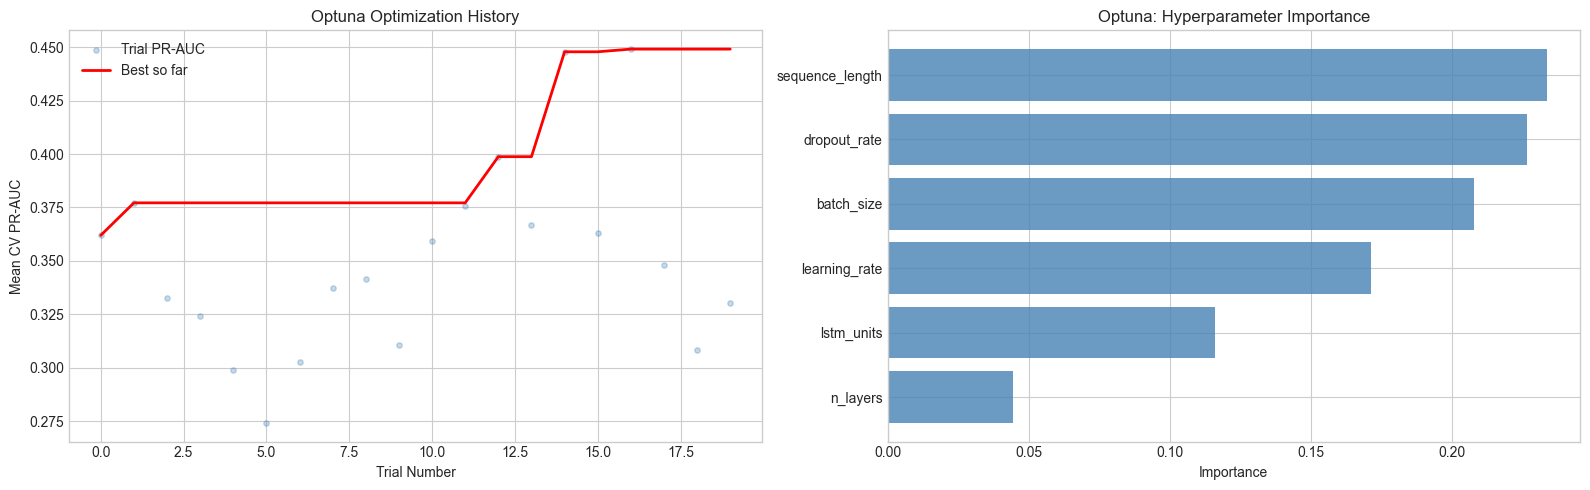

In [12]:
plot_optuna_study(study)

## 4. Evaluate Tuned LSTM

**Checkpointing:** CV predictions (test + validation) are saved to
`data/lstm_eval_checkpoint.pkl`. On restart, if the checkpoint exists and its
`best_params` match the current Optuna best, the evaluation is skipped.
Delete the checkpoint file to force re-evaluation.

In [13]:
# ── Evaluate Tuned HP (with checkpoint save/load) ─────────────────────────────
EVAL_CHECKPOINT = '../data/lstm_eval_checkpoint.pkl'

_loaded_eval = False

if os.path.exists(EVAL_CHECKPOINT):
    with open(EVAL_CHECKPOINT, 'rb') as f:
        _ckpt = pickle.load(f)
    if _ckpt.get('best_params') == best_params:
        tuned_df = _ckpt['tuned_df']
        tuned_pred_df = _ckpt['tuned_pred_df']
        val_pred_df = _ckpt['val_pred_df']
        _loaded_eval = True
        print('Loaded evaluation checkpoint (best_params match).')
    else:
        print('Evaluation checkpoint found but best_params differ. Re-running evaluation...')

if not _loaded_eval:
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    tuned_results = []
    tuned_preds = []
    val_preds = []  # validation predictions for threshold tuning

    best_seq_len = best_params['sequence_length']

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_flat)):
        torch.manual_seed(RANDOM_STATE)
        np.random.seed(RANDOM_STATE)

        X_train_seq, y_train_seq, X_test_seq, y_test_seq, test_meta = \
            create_fold_sequences(df_flat, selected_features, train_idx, test_idx, best_seq_len)

        # Split training sequences for validation-based early stopping
        val_size = int(len(X_train_seq) * VAL_FRAC)
        X_train_inner = X_train_seq[:-val_size]
        y_train_inner = y_train_seq[:-val_size]
        X_val_seq = X_train_seq[-val_size:]
        y_val_seq = y_train_seq[-val_size:]

        n_neg = (y_train_inner == 0).sum()
        n_pos = max((y_train_inner == 1).sum(), 1)
        class_weight = {0: 1.0, 1: n_neg / n_pos}

        model = build_lstm_model(
            sequence_length=best_seq_len,
            n_features=len(selected_features),
            lstm_units=best_params['lstm_units'],
            n_layers=best_params['n_layers'],
            dropout_rate=best_params['dropout_rate'],
            learning_rate=best_params['learning_rate'],
        )

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

        model.fit(
            X_train_inner, y_train_inner,
            validation_data=(X_val_seq, y_val_seq),
            epochs=100,
            batch_size=best_params['batch_size'],
            class_weight=class_weight,
            callbacks=[early_stop],
            verbose=0,
        )

        # Collect validation predictions for threshold tuning
        val_proba = model.predict(X_val_seq, verbose=0).flatten()
        val_preds.append(pd.DataFrame({
            'y_true': y_val_seq, 'y_proba': val_proba, 'fold': fold + 1
        }))

        # Collect test predictions for final evaluation
        y_proba = model.predict(X_test_seq, verbose=0).flatten()
        y_pred = (y_proba >= 0.5).astype(int)

        roc = roc_auc_score(y_test_seq, y_proba)
        prec_arr, rec_arr, _ = precision_recall_curve(y_test_seq, y_proba)
        pr = auc(rec_arr, prec_arr)
        f1 = f1_score(y_test_seq, y_pred)

        test_countries = [m['country'] for m in test_meta]

        tuned_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
        tuned_preds.append(pd.DataFrame({
            'country': test_countries, 'y_true': y_test_seq,
            'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
        }))

        print(f'Fold {fold+1}: ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f} '
              f'| Train seq: {len(X_train_inner)} | Val seq: {len(X_val_seq)} | Test seq: {len(X_test_seq)}')

    tuned_df = pd.DataFrame(tuned_results)
    tuned_pred_df = pd.concat(tuned_preds, ignore_index=True)
    val_pred_df = pd.concat(val_preds, ignore_index=True)

    # Save evaluation checkpoint
    with open(EVAL_CHECKPOINT, 'wb') as f:
        pickle.dump({
            'tuned_df': tuned_df,
            'tuned_pred_df': tuned_pred_df,
            'val_pred_df': val_pred_df,
            'best_params': best_params,
        }, f)
    print('\nSaved evaluation checkpoint.')

print(f'\nTuned LSTM (default threshold=0.5):')
print(f'  Mean ROC-AUC: {tuned_df["roc_auc"].mean():.3f} \u00b1 {tuned_df["roc_auc"].std():.3f}')
print(f'  Mean PR-AUC:  {tuned_df["pr_auc"].mean():.3f} \u00b1 {tuned_df["pr_auc"].std():.3f}')
print(f'  Mean F1:      {tuned_df["f1"].mean():.3f} \u00b1 {tuned_df["f1"].std():.3f}')

Loaded evaluation checkpoint (best_params match).

Tuned LSTM (default threshold=0.5):
  Mean ROC-AUC: 0.644 ± 0.111
  Mean PR-AUC:  0.348 ± 0.160
  Mean F1:      0.312 ± 0.187


## 5. Threshold Selection

Sweep decision thresholds on **validation** predictions (collected during the
evaluation loop) and pick the threshold that maximises mean F1 across folds.
The selected threshold is then applied to **test** predictions for unbiased
reporting — the test data never influences threshold choice.

**Naive baselines we must beat** (to demonstrate the model has learned something useful):
- **Predict-all-positive**: Precision = prevalence, Recall = 1.0, F1 = 2 * prevalence / (1 + prevalence)
- **Predict-all-negative**: F1 = 0 (no true positives)
- **Random classifier**: ROC-AUC = 0.5, PR-AUC ≈ prevalence

In [ ]:
# Sweep on validation predictions to select threshold
(thresholds, mean_val_f1, mean_val_prec, mean_val_rec,
 _, _) = sweep_thresholds(val_pred_df, N_SPLITS)
best_threshold_idx = np.argmax(mean_val_f1)
best_threshold = thresholds[best_threshold_idx]

print(f'Optimal threshold (from validation data): {best_threshold:.2f}')
print(f'  Mean validation F1 at optimal threshold: {mean_val_f1[best_threshold_idx]:.3f}')

# Sweep test metrics for reporting only (threshold already chosen above)
(_, mean_test_f1, mean_test_prec, mean_test_rec,
 naive_f1, mean_prevalence) = sweep_thresholds(tuned_pred_df, N_SPLITS)

# Apply optimal threshold to test predictions
tuned_pred_df['y_pred_opt'] = (tuned_pred_df['y_proba'] >= best_threshold).astype(int)

print(f'\n  Test F1 at optimal threshold:        {mean_test_f1[best_threshold_idx]:.3f}')
print(f'  Test Precision at optimal threshold:  {mean_test_prec[best_threshold_idx]:.3f}')
print(f'  Test Recall at optimal threshold:     {mean_test_rec[best_threshold_idx]:.3f}')
print(f'  Test F1 at default threshold (0.50):  {mean_test_f1[np.argmin(np.abs(thresholds - 0.5))]:.3f}')
print(f'\nNaive baselines (must beat these):')
print(f'  Predict-all-positive F1: {naive_f1:.3f}')
print(f'  Predict-all-negative F1: 0.000')
print(f'  Random classifier ROC-AUC: 0.500')
print(f'  Random classifier PR-AUC:  {mean_prevalence:.3f} (= class prevalence)')

In [ ]:
fig, (ax_val, ax_test) = plt.subplots(1, 2, figsize=(16, 6))

plot_threshold_curves(thresholds, mean_val_f1, mean_val_prec, mean_val_rec,
                      best_threshold, naive_f1,
                      ax=ax_val, title='Validation Metrics (threshold selected here)')

plot_threshold_curves(thresholds, mean_test_f1, mean_test_prec, mean_test_rec,
                      best_threshold, naive_f1,
                      ax=ax_test, title='Test Metrics (generalization)')

plt.suptitle('Threshold Tuning', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Final Model Evaluation

Evaluate the tuned LSTM with the optimized threshold across CV folds and
per-country. All metrics below use the threshold selected on validation data
(Section 5), applied to held-out test folds.

In [15]:
final_df = compute_fold_metrics(tuned_pred_df, N_SPLITS, best_threshold)

Per-Fold Metrics (tuned HP + optimal threshold)
 fold  accuracy  precision  recall    f1  roc_auc  pr_auc
    1     0.272      0.228   1.000 0.371    0.671   0.268
    2     0.629      0.367   0.861 0.515    0.791   0.515
    3     0.748      0.600   0.341 0.435    0.671   0.517
    4     0.740      0.194   0.279 0.229    0.593   0.161
    5     0.870      1.000   0.089 0.163    0.491   0.277

Mean ± Std:
  accuracy    : 0.652 ± 0.229
  precision   : 0.478 ± 0.333
  recall      : 0.514 ± 0.395
  f1          : 0.342 ± 0.145
  roc_auc     : 0.644 ± 0.111
  pr_auc      : 0.348 ± 0.160


### Per-Country Metrics

Aggregate predictions across all CV folds and report metrics per country to
identify which economies the model predicts well vs. poorly:

In [16]:
country_df = compute_country_metrics(tuned_pred_df)

Per-Country Classification Metrics (Tuned Model, Aggregated Across All CV Folds)
             Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Support (pos)  Total
Country                                                                              
Australia       0.600      0.314   0.711 0.435    0.722   0.376             38    175
Canada          0.617      0.250   0.317 0.280    0.588   0.270             41    175
France          0.674      0.255   0.406 0.313    0.659   0.348             32    175
Germany         0.672      0.353   0.649 0.457    0.552   0.258             37    174
Italy           0.718      0.369   0.750 0.495    0.773   0.400             32    174
Japan           0.667      0.365   0.432 0.396    0.610   0.395             44    174
South Korea     0.576      0.323   0.795 0.459    0.651   0.277             39    172
UK              0.715      0.211   0.750 0.329    0.639   0.140             16    172
USA             0.628      0.231   0.333 0.273    0.517   0

### ROC and Precision-Recall Curves

Per-fold ROC curves show probability ranking quality, while PR curves reflect
performance on the minority class (pre-recession periods):

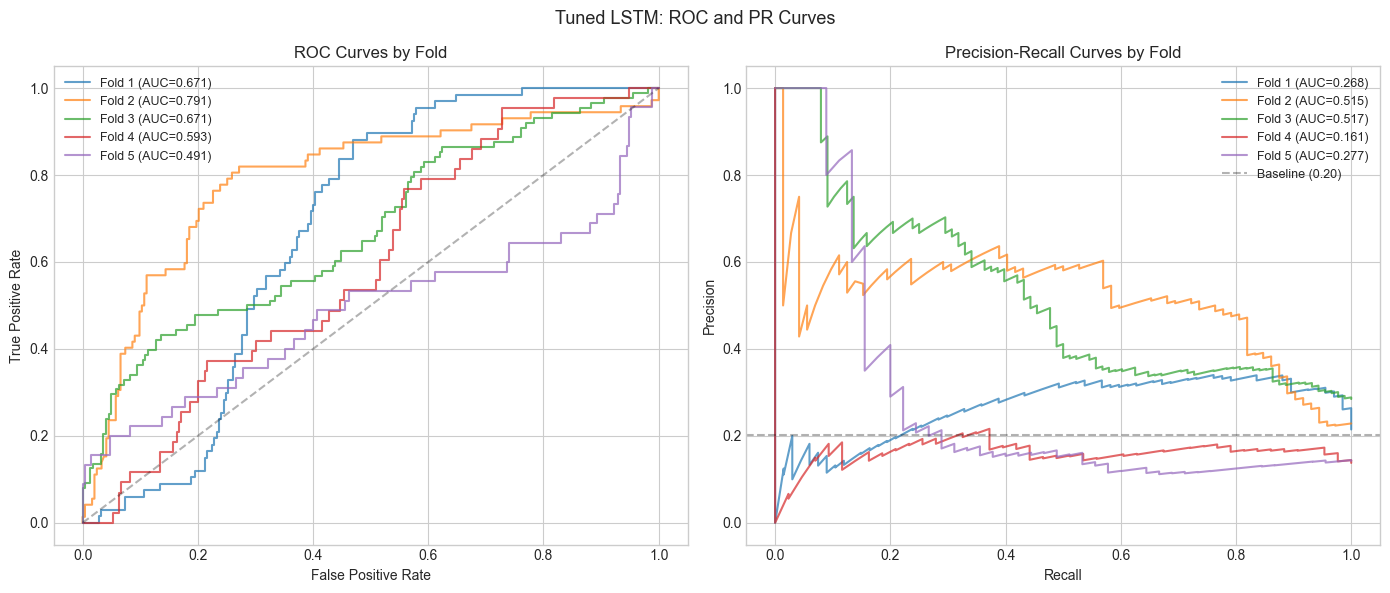

In [17]:
plot_roc_pr_curves(tuned_pred_df, N_SPLITS, 'LSTM')

### Confusion Matrices

Prediction breakdown at the optimal threshold for each CV fold:

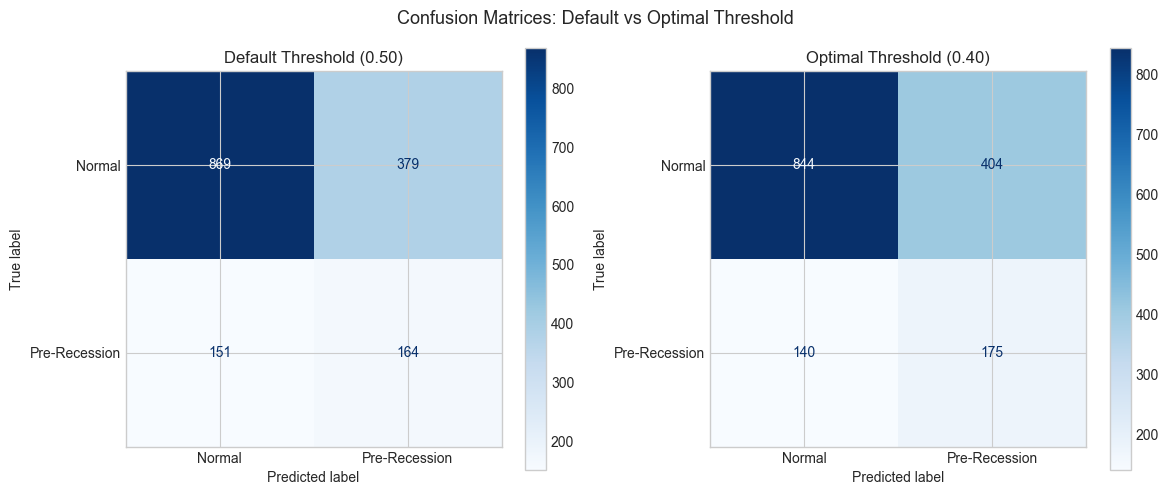

In [18]:
plot_confusion_matrices(tuned_pred_df, best_threshold)

## 7. Baseline vs Tuned Comparison

Compare the baseline LSTM (default hyperparameters, threshold=0.50) against the
Optuna-tuned model with optimized threshold. Naive baselines (predict-all-positive,
predict-all-negative, random classifier) are included as sanity checks.

In [19]:
comparison = build_model_comparison(
    baseline_df, baseline_pred_df,
    tuned_df, tuned_pred_df,
    final_df, best_threshold,
    naive_f1, mean_prevalence,
    model_name='LSTM',
)

LSTM Model Comparison
                               ROC-AUC  PR-AUC    F1  Accuracy  Precision  Recall
Model                                                                            
Naive: Predict All Negative      0.500   0.202 0.000     0.798      0.000   0.000
Naive: Predict All Positive      0.500   0.202 0.332     0.202      0.202   1.000
Baseline (default HP, t=0.50)    0.509   0.318 0.248     0.641      0.250   0.390
Tuned HP (t=0.50)                0.644   0.348 0.312     0.661      0.302   0.521
Tuned HP + Threshold (t=0.40)    0.644   0.348 0.342     0.652      0.302   0.556

Improvement (Tuned HP + Threshold vs Baseline):
  ROC-AUC     : +0.134
  PR-AUC      : +0.030
  F1          : +0.095
  Precision   : +0.052
  Recall      : +0.165

Beats naive baselines?
  F1 (0.342) > predict-all-positive (0.332): True
  ROC-AUC (0.644) > random (0.500): True
  PR-AUC (0.348) > prevalence (0.202): True


## 8. Export Model Configuration

Save the best hyperparameters, selected threshold, feature list, and CV
performance summary to a pickle file for downstream use and cross-model
comparison.

In [20]:
export_model_config(best_params, best_threshold, selected_features, final_df,
                    '../data/lstm_model_config.pkl', dataset='complete')

Exported to: data/lstm_model_config.pkl

Model Configuration:
  Features:    21
  Threshold:   0.40
  Random state: 42

  Hyperparameters:
    batch_size: 16
    dropout_rate: 0.1066
    learning_rate: 0.0005
    lstm_units: 32
    n_layers: 2
    sequence_length: 6

  CV Performance:
    ROC-AUC: 0.644 ± 0.111
    PR-AUC:  0.348 ± 0.160
    F1:      0.342 ± 0.145


## Summary

| Stage | Description |
|-------|-------------|
| Baseline | LSTM (64 units, 1 layer, seq_len=12, dropout=0.2, lr=0.001) |
| HP tuning (Optuna) | 20 trials with TPE; search over seq_len, units, layers, dropout, lr, batch_size |
| Threshold selection | Validation-based: sweep 0.05-0.95 on validation predictions, maximize mean F1 |
| Final evaluation | Best HP + selected threshold, per-fold and per-country metrics |

**LSTM Architecture:**
```
Input(sequence_length, n_features)
-> LSTM(units) [+optional stacked layers]
-> Dropout(rate)
-> Dense(32, relu)
-> Dropout(rate/2)
-> Dense(1, sigmoid)
```

**Key design choices:**
- Sequences created per-country (no cross-country contamination)
- Per-fold StandardScaler and class weights
- Test sequences may look back into training dates (temporal context, not leakage)
- Early stopping on validation loss (`patience=10`, last 20% of training sequences)
- Threshold selected on validation data, metrics reported on test folds (unbiased)
- PR-AUC as primary scoring metric (consistent with XGBoost and Logistic Regression)
- 20 Optuna trials (vs 200 for tabular models) due to training time

**Consistency with other models:**
- `random_state=42` + `torch.manual_seed(42)`
- `TimeSeriesSplit(n_splits=5)` for all cross-validation
- Data cutoff at 2019-01-01 (pre-COVID contamination excluded)
- Same selected features from `selected_features_complete.pkl`
- Same evaluation metrics and per-country analysis
- Same validation-based threshold selection as XGBoost and Logistic Regression

**Backend:** Keras 3 with PyTorch backend (GPU-accelerated via CUDA)

**Exported:** `data/lstm_model_config.pkl`